In [ ]:
%config InlineBackend.figure_formats = ['svg']
from quimb.schematic import Drawing, get_color
import quimb.tensor as qtn
import xyzpy as xyz  # noqa
import matplotlib as mpl  # noqa
import matplotlib.pyplot as plt  # noqa
import numpy as np  # noqa
from quimb.tensor.belief_propagation import gen_region_counts

from utils_draw import (
    draw_cluster,
    get_presets,
    get_axes_area_fraction,
)

# use inter font:
mpl.rcParams["font.family"] = "Inter"
plt.rcParams["mathtext.fontset"] = "cm"

In [2]:
tn = qtn.TN2D_rand(4, 3, 2)
gloops = list(
    tn.gen_gloops_sites(
        sites=[(1, 1), (2, 1)], max_size=5, grow_from="alldangle"
    )
)
gloopsr_cr = tuple(gen_region_counts(gloops))
gloopsr_cr

((frozenset({(0, 0), (0, 1), (1, 0), (1, 1), (2, 1)}), 1),
 (frozenset({(0, 1), (0, 2), (1, 1), (1, 2), (2, 1)}), 1),
 (frozenset({(1, 1), (2, 0), (2, 1), (3, 0), (3, 1)}), 1),
 (frozenset({(1, 1), (2, 1), (2, 2), (3, 1), (3, 2)}), 1),
 (frozenset({(1, 0), (1, 1), (2, 0), (2, 1)}), 1),
 (frozenset({(1, 1), (1, 2), (2, 1), (2, 2)}), 1),
 (frozenset({(1, 0), (1, 1), (2, 1)}), -1),
 (frozenset({(0, 1), (1, 1), (2, 1)}), -1),
 (frozenset({(1, 1), (1, 2), (2, 1)}), -1),
 (frozenset({(1, 1), (2, 0), (2, 1)}), -1),
 (frozenset({(1, 1), (2, 1), (3, 1)}), -1),
 (frozenset({(1, 1), (2, 1), (2, 2)}), -1),
 (frozenset({(1, 1), (2, 1)}), 1))

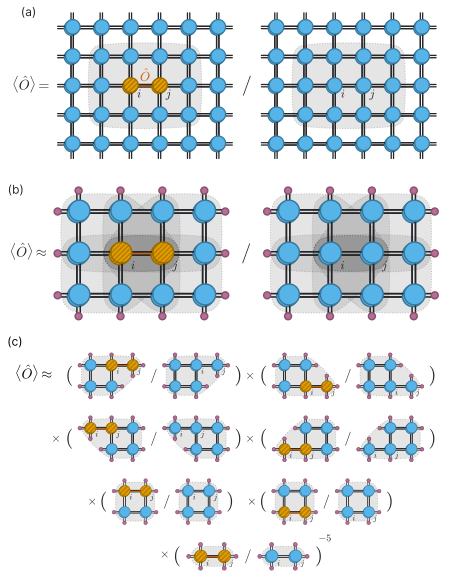

In [3]:
fig = plt.figure(figsize=(6, 7))


# (a) draw full expec
axa = fig.add_axes([0.03, 2 / 3, 0.97, 1])
ax = axa

presets = get_presets(0.65 * get_axes_area_fraction(ax) ** 0.5)
presets["gauge"]["alpha"] = 0.0
d = Drawing(presets=presets, ax=ax, adjust_lims=True)
draw_cluster(
    [(i, j) for i in range(-1, 5) for j in range(-1, 4)],
    d=d,
    targets=[(1, 1), (2, 1)],
    xshift=1,
    highlight=[[(i, j) for i in range(4) for j in range(3)]],
    labels={(1, 1): "$i$", (2, 1): "$j$"},
)
d.text((-0.5 - 1, 2.5 + 1), "(a)", fontsize=12)
d.text((0.3 - 1, 1.05), r"$\langle \hat{O} \rangle=$", fontsize=14, ha="right")
d.text((2.5, 1.3), "$\\hat{O}$", fontsize=13, color=get_color("red"))
d.text((6, 1), "$/$", fontsize=20)
draw_cluster(
    [(i, j) for i in range(-1, 5) for j in range(-1, 4)],
    d=d,
    xshift=8,
    highlight=[[(i, j) for i in range(4) for j in range(3)]],
    labels={(1, 1): "$i$", (2, 1): "$j$"},
)


# (b) draw single cluster
axa = fig.add_axes([0.0, 1 / 3, 1, 1])
ax = axa

presets = get_presets(0.75 * get_axes_area_fraction(ax) ** 0.5)
d = Drawing(presets=presets, ax=ax, adjust_lims=True)
draw_cluster(
    [(i, j) for i in range(4) for j in range(3)],
    d=d,
    targets=[(1, 1), (2, 1)],
    xshift=1,
    highlight=gloops,
    labels={(1, 1): "$i$", (2, 1): "$j$"},
)
d.text((-0.5, 2.5), "(b)", fontsize=12)
d.text(
    (0.3, 1.05), r"$\langle \hat{O} \rangle \approx$", fontsize=14, ha="right"
)
# d.text((2.5, 1.25), "$\\hat{O}$", fontsize=13, color=get_color("red"))
d.text((5, 1), "$/$", fontsize=20)
draw_cluster(
    [(i, j) for i in range(4) for j in range(3)],
    d=d,
    xshift=6,
    highlight=gloops,
    labels={(1, 1): "$i$", (2, 1): "$j$"},
)


# (c) draw cluster expansion
offsetx_axc = 0.03
offsety_axc = 0.09
for (
    i,
    rect,
) in (
    (0, [offsetx_axc + 0.10, offsety_axc + 0.30, 0.40, 0.40]),
    (1, [offsetx_axc + 0.55, offsety_axc + 0.30, 0.40, 0.40]),
    (2, [offsetx_axc + 0.10, offsety_axc + 0.175, 0.40, 0.40]),
    (3, [offsetx_axc + 0.55, offsety_axc + 0.175, 0.40, 0.40]),
    (4, [offsetx_axc + 0.18, offsety_axc + 0.10, 0.30, 0.30]),
    (5, [offsetx_axc + 0.55, offsety_axc + 0.10, 0.30, 0.30]),
    (-1, [offsetx_axc + 0.35, offsety_axc - 0.03, 0.35, 0.35]),
):
    axc = fig.add_axes(rect)
    ax = axc

    gloop = gloopsr_cr[i][0]
    xmin = min(coo[0] for coo in gloop)
    xmax = max(coo[0] for coo in gloop)
    ymin = min(coo[1] for coo in gloop)
    ymax = max(coo[1] for coo in gloop)

    presets = get_presets(1.0 * get_axes_area_fraction(ax) ** 0.5)
    d = Drawing(presets=presets, ax=ax, adjust_lims=True)
    draw_cluster(
        gloop,
        d=d,
        targets=[(1, 1), (2, 1)],
        highlight=[gloop],
        labels={(1, 1): "$i$", (2, 1): "$j$"},
        label_fontsize=8,
    )
    draw_cluster(
        gloop,
        d=d,
        highlight=[gloop],
        xshift=(xmax - xmin) + 2,
        labels={(1, 1): "$i$", (2, 1): "$j$"},
        label_fontsize=8,
    )

    d.text((xmin - 1, (ymax + ymin) / 2), "$($", fontsize=20)
    d.text((xmax + 1, (ymax + ymin) / 2), "$/$", fontsize=14, ha="center")
    d.text((xmax + (xmax - xmin) + 3, (ymax + ymin) / 2), "$)$", fontsize=20)

    if i != 0:
        d.label_ax(-0.04, 0.5, "$\\times$", ha="right", fontsize=12)
    if i == -1:
        d.text((6.25, 1.75), "$-5$")

fig.text(-0.01, 0.560 + offsety_axc, "(c)", fontsize=12, ha="left")
fig.text(
    +0.10,
    0.495 + offsety_axc,
    r"$\langle \hat{O} \rangle \approx$",
    fontsize=14,
    ha="right",
)

plt.show()
plt.close()

In [4]:
d.savefig("fig-0-loop-cluster-expansion.png")